# Heat-Sink Mass, Cost and Manufacturability Analysis

This notebook extends the thermal study into a multi-objective engineering comparison. The three heat-sink geometries are evaluated using their actual dimensions, material density, calculated solid volume, mass, raw-material cost and manufacturability.

**Geometry definitions**

| Design | Base | Fins | Fin dimensions |
|---|---|---:|---|
| Original | 80 × 50 × 5 mm | 8 | 5.5 × 50 × 50 mm |
| Geometry 1 | 60 × 50 × 5 mm | 6 | 5.5 × 50 × 50 mm |
| Geometry 2 | 40 × 50 × 5 mm | 4 | 5.5 × 50 × 50 mm |

The calculation assumes the fins are rectangular solids placed on top of the base, so fin and base volumes do not overlap.

**Repository note:** This notebook consolidates the previous `material.ipynb` and `material_eee.ipynb` work into one materials-analysis notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dimensions (mm)
fin_width_mm = 5.5
fin_height_mm = 50
fin_length_mm = 50
base_width_mm = 50
base_thickness_mm = 5

geometries = {
    "Original": {"base_length_mm": 80, "n_fins": 8},
    "Geometry 1": {"base_length_mm": 60, "n_fins": 6},
    "Geometry 2": {"base_length_mm": 40, "n_fins": 4},
}

materials = {
    "Aluminium 6061-T6": {"density_g_cm3": 2.70, "raw_price_usd_kg": 3.270},
    "Copper C11000": {"density_g_cm3": 8.96, "raw_price_usd_kg": 14.912},
}

fin_volume_mm3 = fin_width_mm * fin_height_mm * fin_length_mm
rows = []
for geometry, g in geometries.items():
    base_volume_mm3 = g["base_length_mm"] * base_width_mm * base_thickness_mm
    total_volume_cm3 = (base_volume_mm3 + g["n_fins"] * fin_volume_mm3) / 1000
    for material, m in materials.items():
        mass_kg = total_volume_cm3 * m["density_g_cm3"] / 1000
        rows.append({
            "Geometry": geometry,
            "Material": material,
            "Volume (cm³)": total_volume_cm3,
            "Mass (kg)": mass_kg,
            "Raw material cost (USD)": mass_kg * m["raw_price_usd_kg"],
        })

mass_results = pd.DataFrame(rows)
mass_results.round(3)


,Geometry,Material,Volume (cm³),Mass (kg),Raw material cost (USD)
0,Original,Aluminium 6061-T6,130.0,0.351,1.148
1,Original,Copper C11000,130.0,1.165,17.369
2,Geometry 1,Aluminium 6061-T6,97.5,0.263,0.861
3,Geometry 1,Copper C11000,97.5,0.874,13.027
4,Geometry 2,Aluminium 6061-T6,65.0,0.176,0.574
5,Geometry 2,Copper C11000,65.0,0.582,8.685


## Volume and Mass Results

The total volumes are **130 cm³** (Original), **97.5 cm³** (Geometry 1), and **65 cm³** (Geometry 2). This means Geometry 1 uses **25% less material** than the original, while Geometry 2 uses **50% less**.

For the same geometry, copper is approximately **3.32× heavier** than aluminium because of its higher density. The original aluminium heat sink is about **0.351 kg**, while the equivalent copper design is about **1.165 kg**.


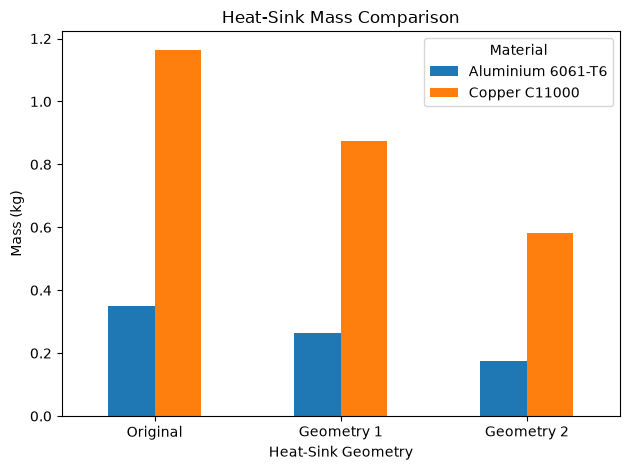

In [2]:
mass_plot = mass_results.pivot(index="Geometry", columns="Material", values="Mass (kg)").reindex(["Original", "Geometry 1", "Geometry 2"])
mass_plot.plot(kind="bar")
plt.xlabel("Heat-Sink Geometry")
plt.ylabel("Mass (kg)")
plt.title("Heat-Sink Mass Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Raw-Material Cost Estimate

The material-only estimate uses the simple relation **cost = mass × benchmark price per kg**. The price inputs are benchmark snapshots, not supplier quotations: **$3.270/kg for aluminium (18 Aug 2026)** and **$14.912/kg for copper (19 Aug 2026)**. They are used only to illustrate the scale of the raw-material trade-off.

Finished heat-sink cost would additionally include extrusion or machining, tooling, cutting, surface finishing, labour, scrap, transport, supplier margin and order quantity. Therefore the values below must **not** be presented as manufacturing quotations.


### Cost Calculation Method

Raw-material cost was estimated using:

**Cost = Heat-sink mass × Material price per kg**

The heat-sink mass was calculated from the geometry volume and material density. This mass was then multiplied by a benchmark raw-material price for aluminium and copper.

The estimated cost represents **raw-material cost only** and does not include manufacturing expenses such as extrusion, machining, surface finishing, labour, tooling, scrap, transport, or supplier margin.

Copper has a substantially higher material-cost penalty because it is both more expensive per kilogram and approximately **3.32 times denser than aluminium** for the same heat-sink geometry.


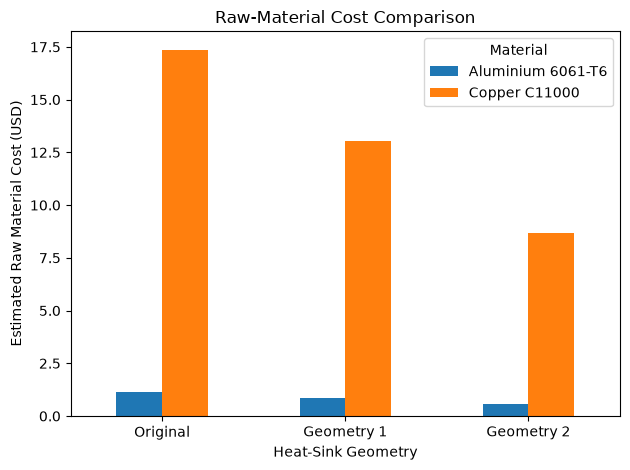

In [3]:
cost_plot = mass_results.pivot(index="Geometry", columns="Material", values="Raw material cost (USD)").reindex(["Original", "Geometry 1", "Geometry 2"])
cost_plot.plot(kind="bar")
plt.xlabel("Heat-Sink Geometry")
plt.ylabel("Estimated Raw Material Cost (USD)")
plt.title("Raw-Material Cost Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Manufacturability and Industrial Use

### Aluminium 6061-T6
Aluminium is the stronger baseline manufacturing choice for this project. 6xxx-series aluminium is widely used for extrusion, and 6061 can also be machined after extrusion. The repeated straight-fin cross-section in this study is compatible with an extrusion-led manufacturing route: produce a long profile, cut it to the required length, machine mounting/contact features, apply any required finish, and assemble the MOSFET/TIM.

Its lower mass also reduces mechanical loading on mounts and enclosures and makes handling and transport easier.

### Copper C11000
Copper provides higher thermal conductivity, but the same geometry is about 3.32× heavier. It also carries a much larger raw-material cost in the benchmark comparison. Copper can be manufactured into thermal components, but for this design the modest temperature improvement does not compensate for the mass and cost penalties. Copper is therefore better reserved for cases where space is tightly constrained or a small additional temperature reduction is genuinely valuable.

### Industrial implication
The three variants preserve a similar fin form while changing overall length and fin count. That supports an industrially realistic strategy based on a common extruded aluminium profile cut to different lengths rather than three completely different manufacturing processes. Geometry 2 minimises material and package size, Geometry 1 provides an intermediate compromise, and the Original geometry maximises thermal margin.


### Manufacturability Comparison

| Factor | Aluminium 6061-T6 | Copper C11000 |
|---|---|---|
| Thermal conductivity | Moderate | High |
| Density | Low | High |
| Heat-sink mass | Lower | Much higher |
| Raw-material cost | Lower | Higher |
| Extrusion suitability | Very good | More limited / more costly |
| Machinability | Good | Good, but heavier to handle |
| Industrial integration | Easier | More demanding |
| Best use case | General heat-sink applications | High heat-flux / space-constrained applications |


## Thermal–Mass Trade-Off

The mass result should be interpreted together with the ANSYS thermal results:

| Aluminium design | Mass | Tj at 1.505 W | Tj at 15 W | Interpretation |
|---|---:|---:|---:|---|
| Original 80 mm | 0.351 kg | 33.108°C* | 103.595°C | Highest mass, strongest thermal margin |
| Geometry 1 60 mm | 0.263 kg | 33.713°C | 111.831°C | 25% lighter; remains below 125°C at 15 W |
| Geometry 2 40 mm | 0.176 kg | 35.475°C | 129.400°C | 50% lighter; compact, but exceeds 125°C target at 15 W |

\*Original value is the coupled 10 A result at the same nominal 1.505 W baseline heat-load case.

Geometry 2 saves **33.3% mass relative to Geometry 1**, but its aluminium junction temperature is about **1.76°C higher at baseline** and **17.57°C higher at 15 W**. This is a clear multi-objective trade-off: the lightest design is attractive near normal operating conditions, whereas Geometry 1 gives a more defensible compromise when high thermal stress must remain below the 125°C project target.


In [4]:
# Export a reproducible summary used elsewhere in the repository
summary = pd.DataFrame([
    {"Geometry": "Original", "Base_Length_mm": 80, "Base_Width_mm": 50, "Base_Thickness_mm": 5, "Number_of_Fins": 8, "Fin_Dimensions_mm": "5.5x50x50", "Total_Volume_cm3": 130.0, "Aluminium_Mass_kg": 0.3510, "Copper_Mass_kg": 1.1648, "Aluminium_Raw_Material_Cost_USD": 0.3510*3.270, "Copper_Raw_Material_Cost_USD": 1.1648*14.912, "Mass_Reduction_vs_Original_pct": 0},
    {"Geometry": "Geometry 1", "Base_Length_mm": 60, "Base_Width_mm": 50, "Base_Thickness_mm": 5, "Number_of_Fins": 6, "Fin_Dimensions_mm": "5.5x50x50", "Total_Volume_cm3": 97.5, "Aluminium_Mass_kg": 0.26325, "Copper_Mass_kg": 0.8736, "Aluminium_Raw_Material_Cost_USD": 0.26325*3.270, "Copper_Raw_Material_Cost_USD": 0.8736*14.912, "Mass_Reduction_vs_Original_pct": 25},
    {"Geometry": "Geometry 2", "Base_Length_mm": 40, "Base_Width_mm": 50, "Base_Thickness_mm": 5, "Number_of_Fins": 4, "Fin_Dimensions_mm": "5.5x50x50", "Total_Volume_cm3": 65.0, "Aluminium_Mass_kg": 0.1755, "Copper_Mass_kg": 0.5824, "Aluminium_Raw_Material_Cost_USD": 0.1755*3.270, "Copper_Raw_Material_Cost_USD": 0.5824*14.912, "Mass_Reduction_vs_Original_pct": 50},
])
summary.to_csv("../data/heatsink_mass_comparison.csv", index=False)
summary.round(3)


,Geometry,Base_Length_mm,Base_Width_mm,Base_Thickness_mm,Number_of_Fins,Fin_Dimensions_mm,Total_Volume_cm3,Aluminium_Mass_kg,Copper_Mass_kg,Aluminium_Raw_Material_Cost_USD,Copper_Raw_Material_Cost_USD,Mass_Reduction_vs_Original_pct
0,Original,80,50,5,8,5.5x50x50,130.0,0.351,1.165,1.148,17.369,0
1,Geometry 1,60,50,5,6,5.5x50x50,97.5,0.263,0.874,0.861,13.027,25
2,Geometry 2,40,50,5,4,5.5x50x50,65.0,0.176,0.582,0.574,8.685,50


## Recommendation from the Material Study

**Aluminium 6061-T6 is recommended as the default heat-sink material.** Copper offers a small thermal benefit, but the equal-geometry mass penalty is about 3.32× and the benchmark raw-material cost per heat sink is much higher.

For geometry selection, **Geometry 1 (60 mm aluminium)** is the strongest balanced recommendation when both normal operation and the 15 W stress criterion matter: it reduces heat-sink mass by 25% relative to the original while remaining below the 125°C project target at 15 W. **Geometry 2 (40 mm aluminium)** is a credible lightweight/compact option if the design is guaranteed to remain near normal electrical operating loads, but it exceeds the 125°C target under the 15 W stress case.
